# ROM-Based Inverse Characterization

Grid search, Nelder-Mead, two-stage sequential, and Horner cross-check for recovering permeability and skin from BHP observations.


In [1]:
import json, pickle, shutil, warnings, time, re
from pathlib import Path
import h5py, numpy as np, scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.ticker import NullLocator
from scipy.interpolate import RBFInterpolator
from scipy.optimize import minimize
from scipy.stats import norm as sp_norm
warnings.filterwarnings('ignore')
from sklearn.utils.extmath import randomized_svd
import gc
import math

plt.rcParams.update({
    'text.usetex': True, 'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb}',
    'font.size': 12, 'axes.labelsize': 12, 'axes.titlesize': 12,
    'legend.fontsize': 11, 'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': False, 'ytick.minor.visible': False,
    'axes.linewidth': 1, 'lines.linewidth': 1.8, 'lines.markersize': 6,
    'axes.grid': False, 'figure.dpi': 150, 'savefig.dpi': 600,
    'savefig.bbox': 'tight', 'legend.frameon': True,
    'legend.framealpha': 1.0, 'legend.edgecolor': 'black',
    'legend.fancybox': False,
})
C1,C2,C3,C4   = '#1a5e9e','#0d6e56','#9b2a1a','#b07318'
C_MRST,C_ROM  = '#2C5F8A','#C0392B'
C_INV,C_GUESS = '#1a7a4a','#b07318'
C_TRUE,C_NM   = '#2C5F8A','#8B0000'

HERE         = Path('.').resolve()
TRAINING_DIR = HERE / '../data/01_training'
VAL_DIR      = HERE / '../data/02_validation'
ROM_DIR      = HERE / '../rom_vrate'
FIG_DIR      = HERE / '../figures_rom_inversion'; FIG_DIR.mkdir(parents=True, exist_ok=True)
sf = lambda n: (plt.savefig(FIG_DIR/n, dpi=600, bbox_inches='tight'),
                print(f'  Saved -> {FIG_DIR/n}'))

# Fixed physics — from run_single_case.m, never change
P_INIT=4500.0; N_CELLS=2500; N_STEPS=350; T_START=0.001; T_END=5000.0
PHI=0.18; CT=1.2e-5; MU_CP=1.2; BO=1.15; H_FT=150.0; RW_FT=0.35
C_WBS=0.003; RE_FT=(50*30/2)*3.28084
WC_IDX = (25-1)*50 + (25-1)   # centre of 50x50 grid, 0-indexed

def load_mat(fp, key):
    try: return sio.loadmat(str(fp), variable_names=[key])[key]
    except NotImplementedError:
        with h5py.File(str(fp), 'r') as f:
            a = f[key][()]; return a.T if a.ndim == 2 else a

def load_well_data(d):
    wd=d/'well_data.mat'
    bhp=load_mat(wd,'bhp_psia').ravel(); t=load_mat(wd,'time_hr').ravel()
    q=load_mat(wd,'rate_STBd').ravel(); dp=load_mat(wd,'delta_p_psi').ravel()
    with open(d/'params.json') as f: pm=json.load(f)
    return bhp,t,q,dp,pm

def physics_ok(k, s):
    kh=k*H_FT; tw=170000*C_WBS*MU_CP*np.exp(0.14*s)/kh
    tp=(PHI*MU_CP*CT*RE_FT**2)/(0.000264*k)*0.1
    n_mtr=int(N_STEPS*np.log10(min(tp,T_END)/max(tw,T_START))/np.log10(T_END/T_START))
    return (tw<T_END) and (tw<tp) and (n_mtr>=15)

def bourdet(t, dp, L=0.2):
    lnt=np.log(t); d=np.full_like(dp,np.nan)
    for i in range(1,len(t)-1):
        il,ir=i-1,i+1
        while il>0 and lnt[i]-lnt[il]<L: il-=1
        while ir<len(t)-1 and lnt[ir]-lnt[i]<L: ir+=1
        dl,dr=lnt[i]-lnt[il],lnt[ir]-lnt[i]
        if dl>0 and dr>0:
            d[i]=((dp[i]-dp[il])/dl*dr+(dp[ir]-dp[i])/dr*dl)/(dl+dr)
    m=np.isfinite(d)&(d>0)&(dp>0); return t[m],dp[m],d[m]

print('Environment ready.')

Environment ready.


In [2]:
_pat = re.compile(r'^k(\d+)_s(\d+)_sched(\d+)$')

def discover(root, label):
    rows = []
    if not root.exists(): print(f'  {label}: not found ({root})'); return rows
    for d in sorted(root.iterdir()):
        m = _pat.match(d.name)
        if m and (d/'well_data.mat').exists():
            rows.append((int(m.group(1)), int(m.group(2)), int(m.group(3)), d))
    return rows

_train = discover(TRAINING_DIR, 'TRAIN')
_val   = discover(VAL_DIR,      'VAL')

K_GRID = sorted(set(c[0] for c in _train))
S_GRID = sorted(set(c[1] for c in _train))
SCHEDS = sorted(set(c[2] for c in _train))
VALID_PAIRS = sorted(set((k,s) for k,s,_,_ in _train if physics_ok(k,s)))

print(f'Training cases : {len(_train)}')
print(f'  k  : {K_GRID}')
print(f'  S  : {S_GRID}')
print(f'  sch: {SCHEDS}')
print(f'Valid (k,S) after physics screen: {len(VALID_PAIRS)}')
print(f'Validation cases: {len(_val)}')
print(f'  k  : {sorted(set(c[0] for c in _val))}')
print(f'  S  : {sorted(set(c[1] for c in _val))}')
print(f'  sch: {sorted(set(c[2] for c in _val))}')

for sub in ['basis','operators','interpolants']:
    (ROM_DIR/sub).mkdir(parents=True, exist_ok=True)

Training cases : 723
  k  : [10, 15, 20, 30, 50, 70, 75, 100, 150, 200, 250, 300]
  S  : [0, 1, 2, 3, 4, 5, 6, 7, 8]
  sch: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Valid (k,S) after physics screen: 102
Validation cases: 804
  k  : [10, 12, 15, 20, 25, 30, 35, 45, 50, 70, 75, 85, 100, 130, 150, 170, 200, 220, 250, 280, 300]
  S  : [0, 1, 2, 3, 4, 5, 6, 7, 8]
  sch: [1, 2, 3, 4, 5, 6, 7, 8, 9]


In [3]:
# ── Memory-efficient POD basis via incremental covariance ─────────────────
# Problem: Z = [2500 x 253050] requires ~5 GB just to exist in RAM.
# np.hstack(snap_cols) fails before SVD even starts.
#
# Solution: build the Gram matrix C = Z @ Z^T = sum_i (col_i @ col_i^T)
# incrementally, one case at a time.  C is only [2500 x 2500] = 50 MB.
# Then eigendecompose C (cheap): C = V Λ V^T  →  singular values σ_i = sqrt(λ_i)
# and left singular vectors U_i = V_i (columns of V).
# This is exact (not approximate) and uses O(n_cells^2) not O(n_cells * n_cols).
#
# Mathematical identity: SVD(Z) gives U, Σ, Vt  where  Z Z^T = U Σ^2 U^T
# So eigendecompose(Z Z^T) gives exactly U and Σ.

print('Building Gram matrix C = Z Z^T incrementally (never forms Z) ...')
t0 = time.perf_counter()
C  = np.zeros((N_CELLS, N_CELLS), dtype=np.float64)  # 50 MB
n_loaded = 0

for k, s in VALID_PAIRS:
    for sid in SCHEDS:
        cd = TRAINING_DIR / f'k{k:03d}_s{s:02d}_sched{sid}'
        try:
            X  = load_mat(cd / 'snapshots_psia.mat', 'X_psia')  # [2500 x 350]
            dX = X - P_INIT
            _, t, _, _, _ = load_well_data(cd)
            dt = np.diff(t, prepend=0.); dt[0] = t[0]
            w  = np.sqrt(dt); w /= (w.mean() + 1e-12)
            # Weighted columns: [2500 x 350]
            Zk = dX * w
            # Accumulate outer product: C += Zk @ Zk^T  [2500 x 2500]
            C += Zk @ Zk.T
            del X, dX, Zk
            n_loaded += 1
        except FileNotFoundError:
            pass

print(f'  {n_loaded} cases accumulated in {time.perf_counter()-t0:.1f}s')
print(f'  Gram matrix C: {C.shape}  ({C.nbytes/1e6:.0f} MB)')

# Eigendecompose C (symmetric, semi-definite) — [2500 x 2500], very fast
print('Eigendecomposing C ...')
t0 = time.perf_counter()
eigvals, eigvecs = np.linalg.eigh(C)   # eigh: exploit symmetry, returns sorted ascending
# Reverse to descending order
eigvals = eigvals[::-1]; eigvecs = eigvecs[:, ::-1]
# Clip small negatives from numerical noise
eigvals = np.maximum(eigvals, 0.0)
sigma   = np.sqrt(eigvals)             # singular values of Z
print(f'  Done {time.perf_counter()-t0:.1f}s  σ₁={sigma[0]:.3f}  σ_last={sigma[-1]:.2e}')
del C; gc.collect()

# Mode count: smallest r satisfying cumulative energy >= 1 - 1e-8
cum_energy = np.cumsum(sigma**2) / np.sum(sigma**2)
N_MODES    = max(int(np.searchsorted(cum_energy, 1 - 1e-8)) + 1, 10)
Vn         = eigvecs[:, :N_MODES]      # left singular vectors = POD modes
print(f'N_MODES = {N_MODES}  (energy = {cum_energy[N_MODES-1]*100:.8f}%)')
print(f'||VᵀV − I||_∞ = {np.abs(Vn.T @ Vn - np.eye(N_MODES)).max():.2e}')
del eigvecs; gc.collect()

np.save(ROM_DIR / 'basis' / 'Vn.npy',    Vn)
np.save(ROM_DIR / 'basis' / 'sigma.npy', sigma)
print(f'Basis saved → {ROM_DIR}/basis/')

Building Gram matrix C = Z Z^T incrementally (never forms Z) ...


  723 cases accumulated in 62.1s
  Gram matrix C: (2500, 2500)  (50 MB)
Eigendecomposing C ...


  Done 2.0s  σ₁=3785776.495  σ_last=0.00e+00
N_MODES = 10  (energy = 99.99999998%)
||VᵀV − I||_∞ = 2.00e-15
Basis saved → E:\MSc thesis zip code\build\repo\ch08_inversion_characterization\notebooks\..\rom_vrate/basis/


In [4]:
def infer_AB(Vn, X_list, U_list, T_list, lam_mult=1.0):
    n_r=Vn.shape[1]; Xr,Ur,Rr,Wr=[],[],[],[]
    for X,u,t in zip(X_list,U_list,T_list):
        dX=X-P_INIT; Xhat=(Vn.T@dX).T
        dt=np.diff(t,prepend=0.); dt[0]=t[0]
        R=np.zeros_like(Xhat); R[0]=Xhat[0]/dt[0]
        for j in range(1,len(t)): R[j]=(Xhat[j]-Xhat[j-1])/dt[j]
        i_s=1; w=np.sqrt(dt[i_s:]); w/=(w.mean()+1e-12)
        Xr.append(Xhat[i_s:]); Ur.append(u[i_s:].reshape(-1,1))
        Rr.append(R[i_s:]);    Wr.append(w)
    Xa=np.vstack(Xr); Ua=np.vstack(Ur); Ra=np.vstack(Rr); Wa=np.concatenate(Wr)
    D=np.hstack([Xa,Ua]); cn=np.linalg.norm(D,axis=0)+1e-12
    Dw=(D/cn)*Wa[:,None]; Rw=Ra*Wa[:,None]
    lam=1e-6*lam_mult*np.trace(Dw.T@Dw)/Dw.shape[1]; nc=Dw.shape[1]
    Da=np.vstack([Dw,np.sqrt(lam)*np.eye(nc)])
    Ra2=np.vstack([Rw,np.zeros((nc,n_r))])
    OT,*_=np.linalg.lstsq(Da,Ra2,rcond=None); OT=OT/cn[:,None]; O=OT.T
    return O[:,:n_r], O[:,n_r:n_r+1]

def infer_CD(Vn, X_list, U_list, BHP_list):
    C_hat=Vn[WC_IDX,:].reshape(1,-1); D_est=[]
    for X,u,bhp in zip(X_list,U_list,BHP_list):
        dX=X-P_INIT; Xhat=(Vn.T@dX).T
        dBHP=(bhp-P_INIT).reshape(-1,1)
        gdp=(C_hat@Xhat.T).T; sdp=dBHP[1:]-gdp[1:]
        uv=u[1:].reshape(-1,1)
        D_est.append(np.vdot(uv,sdp)/(np.vdot(uv,uv)+1e-12))
    return C_hat, np.array([[np.mean(D_est)]])

ops_dir=ROM_DIR/'operators'
if ops_dir.exists(): shutil.rmtree(ops_dir)
ops_dir.mkdir(parents=True)
print(f'Inferring operators for {len(VALID_PAIRS)} (k,S) pairs ...')
results=[]
for k,s in VALID_PAIRS:
    tag=f'k{k:03d}_s{s:02d}'; od=ops_dir/tag; od.mkdir(exist_ok=True)
    X_lst,U_lst,T_lst,B_lst=[],[],[],[]
    for sid in SCHEDS:
        cd=TRAINING_DIR/f'k{k:03d}_s{s:02d}_sched{sid}'
        try:
            X=load_mat(cd/'snapshots_psia.mat','X_psia')
            bhp,t,q,_,_=load_well_data(cd)
            X_lst.append(X); U_lst.append(q); T_lst.append(t); B_lst.append(bhp)
        except FileNotFoundError: pass
    if not X_lst: print(f'  SKIP {tag}'); continue
    stable,lam_mult=False,1.0
    for _ in range(6):
        A,B=infer_AB(Vn,X_lst,U_lst,T_lst,lam_mult)
        ev=np.linalg.eigvals(A)
        if np.all(ev.real<=1e-5): stable=True; break
        lam_mult*=5.0
    emax=ev.real.max()
    if not stable: A=A-(emax+1e-6)*np.eye(N_MODES)
    C,D=infer_CD(Vn,X_lst,U_lst,B_lst)
    for nm,arr in [('A_hat',A),('B_hat',B),('C_hat',C),('D_hat',D)]:
        np.save(od/f'{nm}.npy',arr)
    results.append(dict(tag=tag,k=k,S=s,stable=stable,eig_max=emax,n_scheds=len(X_lst)))
    print(f'  {tag}  {"OK" if stable else "SHIFT"}  lam_max={emax:.2e}  n_scheds={len(X_lst)}')
print(f'Done: {len(results)} operators')

Inferring operators for 102 (k,S) pairs ...


  k010_s00  OK  lam_max=7.08e-07  n_scheds=7


  k010_s01  OK  lam_max=7.08e-07  n_scheds=7


  k010_s02  OK  lam_max=7.08e-07  n_scheds=7


  k010_s03  OK  lam_max=7.08e-07  n_scheds=7


...

  k300_s04  OK  lam_max=2.53e-07  n_scheds=7


  k300_s05  OK  lam_max=2.53e-07  n_scheds=7


  k300_s06  OK  lam_max=2.53e-07  n_scheds=7


  k300_s07  OK  lam_max=2.53e-07  n_scheds=7


  k300_s08  OK  lam_max=2.53e-07  n_scheds=7
Done: 102 operators


In [5]:
pts_lst=[]; A_lst,B_lst,C_lst,D_lst=[],[],[],[]
for r in results:
    A_lst.append(np.load(ops_dir/r['tag']/'A_hat.npy'))
    B_lst.append(np.load(ops_dir/r['tag']/'B_hat.npy'))
    C_lst.append(np.load(ops_dir/r['tag']/'C_hat.npy'))
    D_lst.append(np.load(ops_dir/r['tag']/'D_hat.npy'))
    pts_lst.append([np.log10(r['k']), r['S']])
pts=np.array(pts_lst)
A_arr=np.array(A_lst); B_arr=np.array(B_lst)
C_arr=np.array(C_lst); D_arr=np.array(D_lst)
pts_min=pts.min(0); pts_rng=pts.max(0)-pts.min(0); pts_rng[pts_rng==0]=1.
pts_norm=(pts-pts_min)/pts_rng

def build_rbf(arr,pts_n,smoothing=0.01):
    flat=arr.reshape(len(arr),-1)
    return ([RBFInterpolator(pts_n,flat[:,c],kernel='linear',smoothing=smoothing)
             for c in range(flat.shape[1])], arr.shape[1:])

def eval_op(interps,shape,k,s):
    pn=np.array([[(np.log10(k)-pts_min[0])/pts_rng[0],
                   (s-pts_min[1])/pts_rng[1]]])
    return np.array([f(pn)[0] for f in interps]).reshape(shape)

def _stab(A,m=1e-6):
    lr=np.max(np.real(np.linalg.eigvals(A)))
    return A-(lr+m)*np.eye(len(A)) if lr>=0 else A

print(f'Building RBF over {len(pts)} pts ...')
t0=time.perf_counter()
A_interps,A_shape=build_rbf(A_arr,pts_norm)
B_interps,B_shape=build_rbf(B_arr,pts_norm)
C_interps,C_shape=build_rbf(C_arr,pts_norm)
D_interps,D_shape=build_rbf(D_arr,pts_norm)
print(f'Done {time.perf_counter()-t0:.1f}s')
idir=ROM_DIR/'interpolants'; idir.mkdir(exist_ok=True)
for nm,obj in [('A',{'i':A_interps,'s':A_shape}),('B',{'i':B_interps,'s':B_shape}),
               ('C',{'i':C_interps,'s':C_shape}),('D',{'i':D_interps,'s':D_shape})]:
    with open(idir/f'{nm}_interp.pkl','wb') as f: pickle.dump(obj,f)
print(f'Interpolants saved -> {idir}/')

def rom_bhp(k,s,t,q):
    A=_stab(eval_op(A_interps,A_shape,k,s))
    B=eval_op(B_interps,B_shape,k,s); C=eval_op(C_interps,C_shape,k,s)
    D=eval_op(D_interps,D_shape,k,s)
    dt=np.diff(t,prepend=0.); dt[0]=t[0]; In=np.eye(N_MODES)
    xk=np.zeros(N_MODES); Y=np.zeros(len(t))
    Cv=C.ravel(); Dv=float(D.ravel()[0])
    for j in range(len(t)):
        xk=np.linalg.solve(In-dt[j]*A, xk+dt[j]*B.ravel()*q[j])
        Y[j]=float(np.asarray(Cv@xk).item())+Dv*q[j]
    return P_INIT+Y

print('rom_bhp() ready.')

Building RBF over 102 pts ...
Done 0.0s
Interpolants saved -> E:\MSc thesis zip code\build\repo\ch08_inversion_characterization\notebooks\..\rom_vrate\interpolants/
rom_bhp() ready.


In [6]:
# Scan ALL cases in both directories, sorted by quality tier.
# sched=6 excluded (shut-in — ROM cannot handle q->0 reliably).
ERR_EX=0.03; ERR_GD=0.08; ERR_MG=0.15

print('Scanning all cases (training + validation) ...')
all_scan=[]
for (k,s,sid,d) in sorted(_train+_val, key=lambda x:(x[0],x[1],x[2])):
    if sid==6: continue
    try:
        bhp_fom,t,q,dp,pm=load_well_data(d)
        bhp_rom=rom_bhp(k,s,t,q)
        err=(np.linalg.norm(bhp_rom-bhp_fom)/
             (np.linalg.norm(P_INIT-bhp_fom)+1e-9))
        src='TRAIN' if d.parent==TRAINING_DIR else 'VAL'
        all_scan.append(dict(k=k,s=s,sched=sid,fwd_err=err,
                             bhp=bhp_fom,t=t,q=q,pm=pm,
                             tag=d.name,src=src,path=d))
    except Exception: pass

all_scan.sort(key=lambda x:x['fwd_err'])
_scan_lut={r['tag']:r for r in all_scan}

tiers=[
    (f'EXCELLENT  err < {ERR_EX:.0%}',  lambda e:e<ERR_EX),
    (f'GOOD       {ERR_EX:.0%} <= err < {ERR_GD:.0%}',
                                         lambda e:ERR_EX<=e<ERR_GD),
    (f'MARGINAL   {ERR_GD:.0%} <= err < {ERR_MG:.0%}',
                                         lambda e:ERR_GD<=e<ERR_MG),
    (f'POOR       err >= {ERR_MG:.0%}',  lambda e:e>=ERR_MG),
]
for tname,fn in tiers:
    grp=[r for r in all_scan if fn(r['fwd_err'])]
    if not grp: continue
    print(f'\n-- {tname}  ({len(grp)} cases) --')
    print(f"  {'Case':<32} {'k':>5} {'S':>5} {'sc':>3} {'fwd_err':>9}  src")
    for r in grp:
        print(f"  {r['tag']:<32} {r['k']:>5} {r['s']:>5} {r['sched']:>3}"
              f" {r['fwd_err']:>9.4f}  {r['src']}")
print(f'\nTotal: {len(all_scan)} cases (excl. sched=6)')

Scanning all cases (training + validation) ...



-- EXCELLENT  err < 3%  (1310 cases) --
  Case                                 k     S  sc   fwd_err  src
  k010_s01_sched2                     10     1   2    0.0007  TRAIN
  k010_s01_sched2                     10     1   2    0.0007  VAL
  k050_s07_sched4                     50     7   4    0.0008  TRAIN
  k050_s07_sched4                     50     7   4    0.0008  VAL
  k010_s02_sched2                     10     2   2    0.0009  TRAIN
  k010_s02_sched2                     10     2   2    0.0009  VAL
  k050_s07_sched1                     50     7   1    0.0010  TRAIN
  k050_s07_sched1                     50     7   1    0.0010  VAL
  k030_s01_sched4                     30     1   4    0.0010  TRAIN
  k030_s01_sched4                     30     1   4    0.0010  VAL
  k070_s07_sched4                     70     7   4    0.0011  TRAIN
  k070_s07_sched4                     70     7   4    0.0011  VAL
  k050_s07_sched3                     50     7   3    0.0011  TRAIN
  k050_s07_sched3    

In [7]:


# =======================================================================
#  MANUAL BATCH CONFIGURATION
# =======================================================================
cases_to_run = [
    {'k': 25.0,  's': 5.0, 'sched': 3},
    {'k': 45.0,  's': 7.0, 'sched': 9},
    {'k': 85.0, 's': 3.0, 'sched': 4},
    {'k': 130.0, 's': 5.0, 'sched': 6},
    {'k': 220.0, 's': 7.0, 'sched': 9},
    {'k': 280.0, 's': 5.0, 'sched': 6}

]
# =======================================================================

batch_results = []   # replaces inv_results — stores everything for plotting

for idx, cfg in enumerate(cases_to_run):
    K_MAN  = float(cfg['k'])
    S_MAN  = float(cfg['s'])
    SID_MAN = int(cfg['sched'])
    folder  = f"k{int(round(K_MAN)):03d}_s{int(round(S_MAN)):02d}_sched{SID_MAN}"

    print(f"\n{'='*70}")
    print(f" CASE {idx+1}/{len(cases_to_run)}: k={K_MAN} mD, S={S_MAN}, sched={SID_MAN}")
    print(f" Folder: {folder}")
    print(f"{'='*70}")

    # ── Locate data ───────────────────────────────────────────────────
    target = None
    for base in [VAL_DIR, TRAINING_DIR]:
        p = base / folder
        if p.exists() and (p / 'well_data.mat').exists():
            target = p; break

    if target is None:
        print(f'  [NOT FOUND] {folder}')
        nearby = [r for r in all_scan
                  if abs(r['k']-K_MAN) < K_MAN*0.25 and abs(r['s']-S_MAN) < 2][:5]
        if nearby:
            print('  Nearest available:')
            for r in nearby:
                print(f"    {r['tag']:<32} fwd_err={r['fwd_err']:.4f} [{r['src']}]")
        continue

    bhp_obs, t_obs, q_obs, _, pm = load_well_data(target)
    q_ref = float(np.atleast_1d(pm['rates_STBd'])[0])

    # ── Forward error ─────────────────────────────────────────────────
    fwd = _scan_lut.get(folder, {}).get('fwd_err', None)
    if fwd is None:
        try:
            bhp_rom = rom_bhp(K_MAN, S_MAN, t_obs, q_obs)
            fwd = (np.linalg.norm(bhp_rom - bhp_obs) /
                   (np.linalg.norm(P_INIT - bhp_obs) + 1e-9))
        except: fwd = np.nan
    tier = ('EXCELLENT' if fwd < ERR_EX else 'GOOD' if fwd < ERR_GD
            else 'MARGINAL' if fwd < ERR_MG else 'POOR') if fwd and np.isfinite(fwd) else '?'
    print(f'  Source : {target}')
    print(f'  fwd_err: {fwd:.4f}  [{tier}]')

    # ── Weights & misfit ──────────────────────────────────────────────
    dt_w = np.diff(t_obs, prepend=0.); dt_w[0] = t_obs[0]
    w = np.sqrt(dt_w); w /= w.mean()
    def misfit(k, s, _t=t_obs, _q=q_obs, _p=bhp_obs, _w=w):
        try:
            r = _w * (rom_bhp(k, s, _t, _q) - _p)
            return 0.5 * np.dot(r, r)
        except: return np.nan

    # ── Method A: Grid Search ─────────────────────────────────────────
    NK, NS  = 200, 200
    k_vec   = np.logspace(np.log10(5), np.log10(300), NK)
    s_vec   = np.linspace(0, 8, NS)
    kk, ss  = np.meshgrid(k_vec, s_vec)
    JJ      = np.full_like(kk, np.nan)
    print(f"\n  Grid search {NK}x{NS}={NK*NS} pts ...")
    t0 = time.perf_counter()
    for i, si in enumerate(s_vec):
        for j, kj in enumerate(k_vec):
            JJ[i, j] = misfit(kj, si)
    print(f"  Done {time.perf_counter()-t0:.1f}s")

    idx_min = np.unravel_index(np.nanargmin(JJ), JJ.shape)
    K_GS = k_vec[idx_min[1]]; S_GS = s_vec[idx_min[0]]; J_min = JJ[idx_min]
    sigma2 = J_min / max(len(t_obs) - 2, 1)
    if sigma2 > 1e-10:
        J_1sig = J_min + 0.5 * 2.30 * sigma2          # chi²(2) 68% joint CI
        in_cr  = JJ <= J_1sig
        k_ci = (kk[in_cr].min(), kk[in_cr].max())
        s_ci = (ss[in_cr].min(), ss[in_cr].max())
        ci_str = f"k∈[{k_ci[0]:.1f},{k_ci[1]:.1f}] S∈[{s_ci[0]:.2f},{s_ci[1]:.2f}]"
    else:
        J_1sig = J_min + 1e-6; k_ci = (K_GS,K_GS); s_ci = (S_GS,S_GS)
        ci_str = "degenerate"

    # ── Method C: Nelder-Mead ─────────────────────────────────────────
    _nc = [0]; _nm_path = []
    def _mj(xi):
        _nc[0] += 1
        J = misfit(10**xi[0], xi[1])
        _nm_path.append((10**xi[0], xi[1], J))
        return J
    nm  = minimize(_mj, [np.log10(K_GS), S_GS], method='Nelder-Mead',
                   options=dict(xatol=1e-5, fatol=1e-10, maxiter=1000, adaptive=True))
    K_NM = 10**nm.x[0]; S_NM = nm.x[1]
    nm_path = np.array(_nm_path)          # columns: k, S, J

    # ── Method B: Two-Stage (iterated) ───────────────────────────────
    S_NOM = float(np.mean(list(set(s for _, s in VALID_PAIRS))))
    J_k   = np.array([misfit(kj, S_NOM) for kj in k_vec]); K_B1 = k_vec[np.nanargmin(J_k)]
    J_s   = np.array([misfit(K_B1, si)  for si in s_vec]); S_B1 = s_vec[np.nanargmin(J_s)]
    J_k2  = np.array([misfit(kj, S_B1)  for kj in k_vec]); K_B  = k_vec[np.nanargmin(J_k2)]
    J_s2  = np.array([misfit(K_B,  si)  for si in s_vec]); S_B  = s_vec[np.nanargmin(J_s2)]

    # ── Horner ────────────────────────────────────────────────────────
    dp_c = np.clip(P_INIT - bhp_obs, 1e-2, None)
    tb, _, db = bourdet(t_obs, dp_c, L=0.15)
    t_wbs = 170000 * C_WBS * MU_CP * np.exp(0.14 * S_NM) / (K_NM * H_FT)
    t_pss = (PHI * MU_CP * CT * RE_FT**2) / (0.000264 * K_NM) * 0.1
    mtr   = (tb > t_wbs) & (tb < t_pss * 0.5)
    dp_flat  = float(np.nanmedian(db[mtr])) if mtr.any() else float(np.nanmedian(db))
    k_horner = 70.6 * q_ref * MU_CP * BO / (dp_flat * H_FT)

    # ── Console summary ───────────────────────────────────────────────
    print(f"\n  {'Method':<22} {'k [mD]':>8} {'k%err':>7} {'S':>7} {'S err':>7} {'calls':>6}")
    print("  " + "-"*56)
    print(f"  {'True (FOM)':<22} {K_MAN:>8.1f} {'—':>7} {S_MAN:>7.2f} {'—':>7}")
    print(f"  {'A: Grid Search':<22} {K_GS:>8.2f} {abs(K_GS-K_MAN)/K_MAN*100:>6.1f}% {S_GS:>7.2f} {abs(S_GS-S_MAN):>7.3f} {NK*NS:>6}")
    print(f"  {'C: Nelder-Mead':<22} {K_NM:>8.3f} {abs(K_NM-K_MAN)/K_MAN*100:>6.2f}% {S_NM:>7.4f} {abs(S_NM-S_MAN):>7.4f} {_nc[0]:>6}")
    print(f"  {'B: Two-Stage':<22} {K_B:>8.2f}  {abs(K_B-K_MAN)/K_MAN*100:>6.1f}% {S_B:>7.2f} {abs(S_B-S_MAN):>7.3f} {'~110':>6}")
    print(f"  {'Horner (MTR)':<22} {k_horner:>8.2f} {abs(k_horner-K_MAN)/K_MAN*100:>6.1f}%   dp'={dp_flat:.3f} psi")
    print(f"  68% CI: {ci_str}  |  fwd_err: {fwd:.4f} [{tier}]")

    # ── Store for table + landscape ───────────────────────────────────
    batch_results.append({
        'name':     f"$k={K_MAN:.0f}$, $S={S_MAN}$, sched {SID_MAN}",
        'K_TRUE': K_MAN,    'S_TRUE': S_MAN,
        'K_GS':   K_GS,     'S_GS':   S_GS,
        'K_NM':   K_NM,     'S_NM':   S_NM,
        'K_B':    K_B,      'S_B':    S_B,
        'nm_path': nm_path,
        'K_B1': K_B1, 'S_B1': S_B1,  
        'k_horner': k_horner,
        'k_err_nm': abs(K_NM - K_MAN) / K_MAN * 100,
        's_err_nm': abs(S_NM - S_MAN),
        'k_err_gs': abs(K_GS - K_MAN) / K_MAN * 100,
        's_err_gs': abs(S_GS - S_MAN),
        'k_err_b':  abs(K_B  - K_MAN) / K_MAN * 100,
        's_err_b':  abs(S_B  - S_MAN),
        'nm_calls': _nc[0],
        'dp_flat':  dp_flat,
        'fwd_err':  fwd,
        'tier':     tier,
        'ci_str':   ci_str,
        'kk': kk, 'ss': ss, 'JJ': JJ,
        'k_vec': k_vec, 's_vec': s_vec,
        'J_k': J_k, 'J_s2': J_s2,
        'sigma2': sigma2, 'J_1sig': J_1sig,
        'S_NOM': S_NOM,
    })

print(f"\nBatch done: {len(batch_results)}/{len(cases_to_run)} processed.")


 CASE 1/6: k=25.0 mD, S=5.0, sched=3
 Folder: k025_s05_sched3
  Source : E:\MSc thesis zip code\build\repo\ch08_inversion_characterization\notebooks\..\data\02_validation\k025_s05_sched3
  fwd_err: 0.0029  [EXCELLENT]

  Grid search 200x200=40000 pts ...


  Done 173.9s



  Method                   k [mD]   k%err       S   S err  calls
  --------------------------------------------------------
  True (FOM)                 25.0       —    5.00       —
  A: Grid Search            23.88    4.5%    4.42   0.578  40000
  C: Nelder-Mead           24.309   2.76%  4.6469  0.3531    262
  B: Two-Stage              22.92     8.3%    3.90   1.101   ~110
  Horner (MTR)              23.55    5.8%   dp'=33.092 psi
  68% CI: k∈[23.9,23.9] S∈[4.42,4.42]  |  fwd_err: 0.0029 [EXCELLENT]

 CASE 2/6: k=45.0 mD, S=7.0, sched=9
 Folder: k045_s07_sched9
  Source : E:\MSc thesis zip code\build\repo\ch08_inversion_characterization\notebooks\..\data\02_validation\k045_s07_sched9
  fwd_err: 0.0014  [EXCELLENT]

  Grid search 200x200=40000 pts ...


  Done 173.2s



  Method                   k [mD]   k%err       S   S err  calls
  --------------------------------------------------------
  True (FOM)                 45.0       —    7.00       —
  A: Grid Search            45.19    0.4%    7.12   0.116  40000
  C: Nelder-Mead           44.538   1.03%  6.8745  0.1255    263
  B: Two-Stage              36.04    19.9%    3.98   3.020   ~110
  Horner (MTR)              42.18    6.3%   dp'=13.858 psi
  68% CI: k∈[45.2,45.2] S∈[7.12,7.12]  |  fwd_err: 0.0014 [EXCELLENT]

 CASE 3/6: k=85.0 mD, S=3.0, sched=4
 Folder: k085_s03_sched4
  Source : E:\MSc thesis zip code\build\repo\ch08_inversion_characterization\notebooks\..\data\02_validation\k085_s03_sched4
  fwd_err: 0.0026  [EXCELLENT]

  Grid search 200x200=40000 pts ...


...


  Method                   k [mD]   k%err       S   S err  calls
  --------------------------------------------------------
  True (FOM)                130.0       —    5.00       —
  A: Grid Search           149.04   14.6%    6.87   1.874  40000
  C: Nelder-Mead          150.102  15.46%  7.0000  2.0000    227
  B: Two-Stage             121.33     6.7%    4.02   0.980   ~110
  Horner (MTR)             122.03    6.1%   dp'=4.258 psi
  68% CI: k∈[149.0,149.0] S∈[6.87,6.87]  |  fwd_err: 0.0061 [EXCELLENT]

 CASE 5/6: k=220.0 mD, S=7.0, sched=9
 Folder: k220_s07_sched9
  Source : E:\MSc thesis zip code\build\repo\ch08_inversion_characterization\notebooks\..\data\02_validation\k220_s07_sched9
  fwd_err: 0.0125  [EXCELLENT]

  Grid search 200x200=40000 pts ...


  Done 171.9s



  Method                   k [mD]   k%err       S   S err  calls
  --------------------------------------------------------
  True (FOM)                220.0       —    7.00       —
  A: Grid Search           224.92    2.2%    7.64   0.638  40000
  C: Nelder-Mead          226.720   3.05%  7.7270  0.7270   3814
  B: Two-Stage             179.36    18.5%    4.02   2.980   ~110
  Horner (MTR)             206.49    6.1%   dp'=2.831 psi
  68% CI: k∈[224.9,224.9] S∈[7.64,7.64]  |  fwd_err: 0.0125 [EXCELLENT]

 CASE 6/6: k=280.0 mD, S=5.0, sched=6
 Folder: k280_s05_sched6
  Source : E:\MSc thesis zip code\build\repo\ch08_inversion_characterization\notebooks\..\data\02_validation\k280_s05_sched6
  fwd_err: 0.0189  [EXCELLENT]

  Grid search 200x200=40000 pts ...


  Done 171.9s



  Method                   k [mD]   k%err       S   S err  calls
  --------------------------------------------------------
  True (FOM)                280.0       —    5.00       —
  A: Grid Search           293.89    5.0%    5.75   0.749  40000
  C: Nelder-Mead          292.365   4.42%  5.6738  0.6738    241
  B: Two-Stage             265.16     5.3%    4.10   0.899   ~110
  Horner (MTR)             264.89    5.4%   dp'=1.962 psi
  68% CI: k∈[293.9,293.9] S∈[5.75,5.75]  |  fwd_err: 0.0189 [EXCELLENT]

Batch done: 6/6 processed.


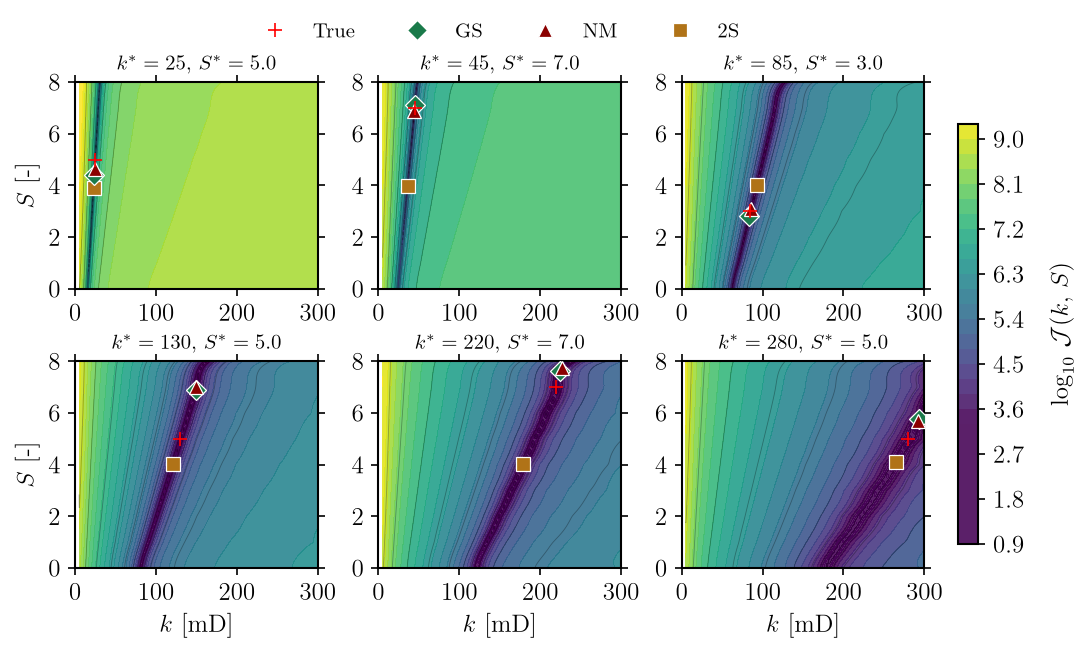

In [8]:
# ── Part 2: Batch Misfit Landscape Grid ───────────────────────────────────
N    = len(batch_results)
cols = min(N, 3)
rows = math.ceil(N / cols)

fig, axes = plt.subplots(rows, cols,
                         figsize=(2.5 * cols, 2 * rows))
axes_flat = axes.flatten()

all_Jlog    = [np.log10(np.clip(r['JJ'], 1e-4, None)) for r in batch_results]
global_vmin = min(np.nanpercentile(J, 2)  for J in all_Jlog)
global_vmax = max(np.nanpercentile(J, 98) for J in all_Jlog)

for i, res in enumerate(batch_results):
    ax   = axes_flat[i]
    Jlog = all_Jlog[i]

    cf = ax.contourf(res['kk'], res['ss'], Jlog, levels=28, cmap='viridis',
                     vmin=global_vmin, vmax=global_vmax, alpha=0.88)
    ax.contour(res['kk'], res['ss'], Jlog, levels=10,
               colors='k', linewidths=0.4, alpha=0.3)

    if res['sigma2'] > 1e-10:
        ax.contour(res['kk'], res['ss'], res['JJ'], levels=[res['J_1sig']],
                   colors=[C_INV], linewidths=1.5, linestyles='--')

    ax.plot(res['K_TRUE'], res['S_TRUE'], '+',
            color=C_TRUE,  ms=7, mec='red', mew=0.8, zorder=12, label='True')
    ax.plot(res['K_GS'],   res['S_GS'],   'D',
            color=C_INV,   ms=7,  mec='white', mew=0.6, zorder=10, label='GS')
    ax.plot(res['K_NM'],   res['S_NM'],   '^',
            color=C_NM,    ms=7,  mec='white', mew=0.6, zorder=11, label='NM')
    ax.plot(res['K_B'],    res['S_B'],    's',
            color=C_GUESS, ms=7,  mec='white', mew=0.6, zorder=9,  label='2S')

#     ax.text(0.03, 0.96,
#             f"$k^*={res['K_TRUE']:.0f}$, $S^*={res['S_TRUE']}$\n"
#             f"$\\hat{{k}}_{{\\rm NM}}={res['K_NM']:.1f}$\n"
#             f"$\\hat{{S}}_{{\\rm NM}}={res['S_NM']:.2f}$",
#             transform=ax.transAxes, fontsize=8, va='top', ha='left',
#             bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.85))

    
    ax.set_title(f"$k^*={res['K_TRUE']:.0f}$, $S^*={res['S_TRUE']}$",
                 fontsize=10, pad=6)
    ax.set_xlim([0, 300])
    ax.set_ylim(res['s_vec'][0], res['s_vec'][-1])

    if i >= N - cols:
        ax.set_xlabel(r'$k$ [mD]')
    if i % cols == 0:
        ax.set_ylabel(r'$S$ [-]')

    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())

for i in range(N, len(axes_flat)):
    axes_flat[i].set_visible(False)

h, l = axes_flat[0].get_legend_handles_labels()
fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, 1.05),
           ncol=4, frameon=False, fontsize=10)

fig.subplots_adjust(right=0.88, top=0.92, wspace=0.25, hspace=0.35)
cbar_ax = fig.add_axes([0.91, 0.15, 0.018, 0.70])
cbar    = fig.colorbar(cf, cax=cbar_ax)
cbar.set_label(r'$\log_{10}\,\mathcal{J}(k,\,S)$', rotation=90, labelpad=12)
cbar.ax.yaxis.set_minor_locator(NullLocator())

plt.savefig(FIG_DIR / 'fig_inv_batch_landscape.pdf', dpi=600, bbox_inches='tight')
plt.show()

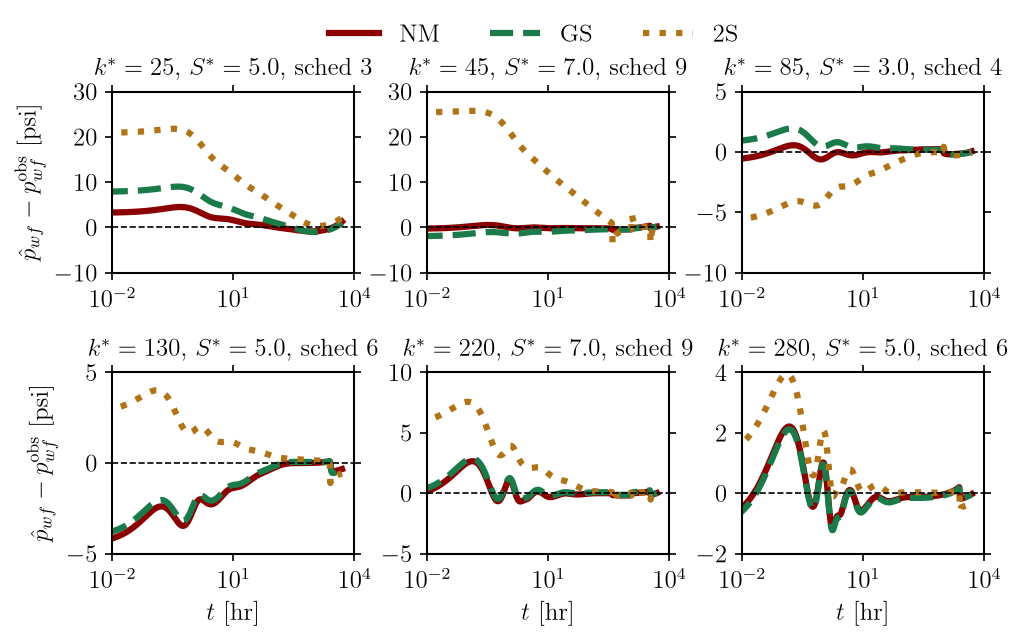

In [9]:
# ── Residuals grid: all cases × all methods ───────────────────────────────
import math, re as _re

N    = len(batch_results)
cols = min(N, 3)
rows = math.ceil(N / cols)

fig, axes = plt.subplots(rows, cols, figsize=(2.5*cols, 2*rows), squeeze=False)
axes_flat = axes.flatten()
# (y_lo, y_hi) per case 
Y_LIMS = [(-10, 30), (-10, 30), (-10, 5),
          (-5, 5),  (-5, 10),  (-2, 4)]

for i, res in enumerate(batch_results):
    ax = axes_flat[i]

    sid    = int(_re.search(r'sched (\d+)', res['name']).group(1))
    folder = f"k{int(round(res['K_TRUE'])):03d}_s{int(round(res['S_TRUE'])):02d}_sched{sid}"
    target = next(b / folder for b in [VAL_DIR, TRAINING_DIR]
                  if (b / folder / 'well_data.mat').exists())
    bhp_obs, t_obs, q_obs, _, _ = load_well_data(target)

    # Residuals for all three methods; track min/max for y-capping
    r_all = []
    for K_, S_, col_, ls_, lbl_ in [
        (res['K_NM'], res['S_NM'], C_NM,    '-',  'NM'),
        (res['K_GS'], res['S_GS'], C_INV,   '--', 'GS'),
        (res['K_B'],  res['S_B'],  C_GUESS, ':',  '2S'),
    ]:
        r_ = rom_bhp(K_, S_, t_obs, q_obs) - bhp_obs
        r_all.append(r_)
        ax.semilogx(t_obs, r_, color=col_, lw=3, ls=ls_, label=lbl_)

    ax.axhline(0, color='k', lw=0.8, ls='--')

    # Title carries the case values
    ax.set_title(f"$k^*={res['K_TRUE']:.0f}$, $S^*={res['S_TRUE']}$, sched {sid}",
                 fontsize=12, pad=8)

    # x: fixed log range; y: capped to nearest integer outside data range
    ax.set_xlim(1e-2, 1e4)
    r_lo = np.floor(min(r.min() for r in r_all))
    r_hi = np.ceil(max(r.max() for r in r_all))
    ax.set_ylim(*Y_LIMS[i])
    if i < 2:                      # first two panels only
        ax.set_yticks(np.linspace(Y_LIMS[i][0], Y_LIMS[i][1], 5))

    if i >= N - cols:
        ax.set_xlabel(r'$t$ [hr]', fontsize=12)
    if i % cols == 0:
        ax.set_ylabel(r'$\hat{p}_{wf}-p^{\rm obs}_{wf}$ [psi]', fontsize=12)
    ax.tick_params(labelsize=12)
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())

for i in range(N, len(axes_flat)):
    axes_flat[i].set_visible(False)

# One shared legend (colours/linestyles identical across panels)
h, l = axes_flat[0].get_legend_handles_labels()
fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, 1.03),
           ncol=3, frameon=False, fontsize=12)

fig.subplots_adjust(wspace=0.30, hspace=0.55)
plt.savefig(FIG_DIR / 'fig_inv_batch_residuals.pdf', dpi=600, bbox_inches='tight')
plt.show()

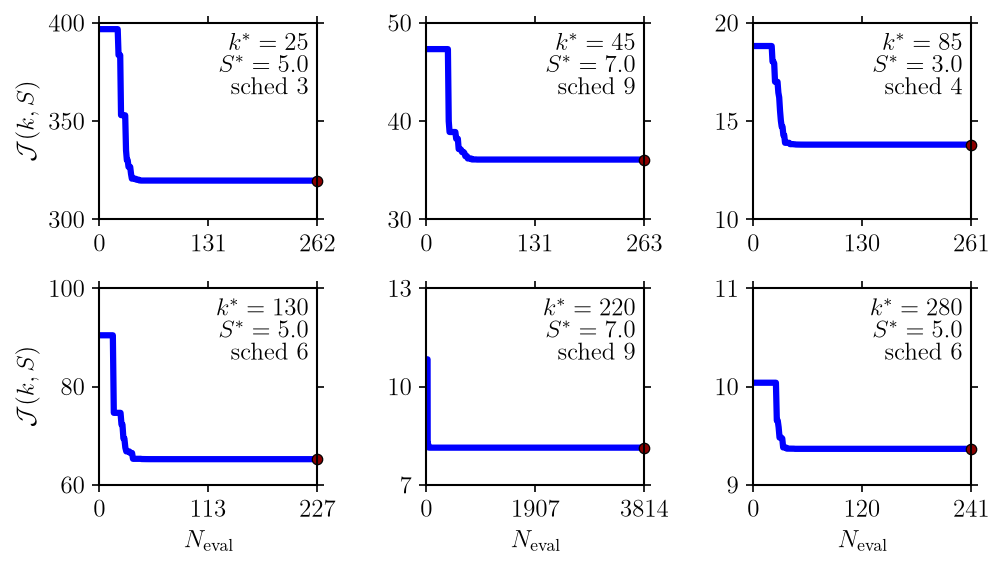

In [10]:
# ── NM convergence grid: J vs ROM evaluations (linear y, manual ticks) ────
import math, re as _re

# ═══════════════════════════════════════════════════════════════════════
#  MANUAL Y-TICKS (raw J values, one entry per case, order = cases_to_run)
#  None → automatic snug limits with 3 evenly spaced ticks.
# ═══════════════════════════════════════════════════════════════════════
Y_TICKS = [
    [300, 350, 400],                    # case 1
    [30, 40, 50],                    # case 2
    [10, 15, 20],                    # case 3   e.g. [10, 15, 20]
    [60, 80, 100],                    # case 4
    [7, 10, 13],                    # case 5
    [9, 10, 11],                    # case 6
]
# ═══════════════════════════════════════════════════════════════════════

N    = len(batch_results)
cols = min(N, 3)
rows = math.ceil(N / cols)

fig, axes = plt.subplots(rows, cols, figsize=(2.5*cols, 2*rows), squeeze=False)
axes_flat = axes.flatten()

def _nice(x):
    """Round x to 2 significant figures (for clean auto tick labels)."""
    if x == 0: return 0.0
    p = 10.0 ** (np.floor(np.log10(abs(x))) - 1)
    return np.round(x / p) * p

for i, res in enumerate(batch_results):
    ax  = axes_flat[i]
    sid = int(_re.search(r'sched (\d+)', res['name']).group(1))

    J_best = np.minimum.accumulate(res['nm_path'][:, 2])
    evals  = np.arange(1, len(J_best) + 1)
    n_end  = int(evals[-1])

    ax.plot(evals, J_best, lw=3, color='blue')
    ax.plot(n_end, J_best[-1], 'o', color=C_NM, ms=5, mec='k', mew=0.6,
            clip_on=False)

    ax.text(0.96, 0.95,
            f"$k^*={res['K_TRUE']:.0f}$\n$S^*={res['S_TRUE']}$\nsched {sid}",
            transform=ax.transAxes, fontsize=12, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.85))

    # ── x: linear, ticks at limits + midpoint ──────────────────────────
    ax.set_xlim(0, n_end)
    ax.set_xticks([0, n_end // 2, n_end])

    # ── y: manual ticks if given, else snug limits + 3 nice ticks ──────
    if Y_TICKS[i] is not None:
        yt = np.asarray(Y_TICKS[i], dtype=float)
        ax.set_ylim(yt.min(), yt.max())
        ax.set_yticks(yt)
    else:
        span = J_best.max() - J_best.min()
        pad  = 0.06 * span if span > 0 else 0.5
        y_lo = _nice(J_best.min() - pad)
        y_hi = _nice(J_best.max() + pad)
        ax.set_ylim(y_lo, y_hi)
        ax.set_yticks([y_lo, _nice((y_lo + y_hi) / 2), y_hi])

    # ── y-label on left column only
    if i % cols == 0:
        ax.set_ylabel(r'$\mathcal{J}(k,S)$', fontsize=12)
        
    # ── x-label on bottom row only (NEW)
    if i >= N - cols:
        ax.set_xlabel(r'$N_{\rm eval}$', fontsize=12)
    ax.tick_params(labelsize=12)
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())

for i in range(N, len(axes_flat)):
    axes_flat[i].set_visible(False)

fig.subplots_adjust(wspace=0.50, hspace=0.35)
plt.savefig(FIG_DIR / 'fig_inv_nm_convergence.pdf', dpi=600, bbox_inches='tight')
plt.show()